In [1]:
import nltk                                # Python library for NLP
from nltk.corpus import twitter_samples    # sample Twitter dataset from NLTK
import matplotlib.pyplot as plt            # library for visualization
import random                              # pseudo-random number generator

In [2]:
# downloads sample twitter dataset. uncomment the line below if running on a local machine.
nltk.download('twitter_samples')

[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/sooreoluwa/nltk_data...
[nltk_data]   Unzipping corpora/twitter_samples.zip.


True

In [6]:
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

In [7]:
print('Number of positive tweets: ', len(all_positive_tweets))
print('Number of negative tweets: ', len(all_negative_tweets))

print('\nThe type of all_positive_tweets is: ', type(all_positive_tweets))
print('The type of a tweet entry is: ', type(all_negative_tweets[0]))

Number of positive tweets:  5000
Number of negative tweets:  5000

The type of all_positive_tweets is:  <class 'list'>
The type of a tweet entry is:  <class 'str'>


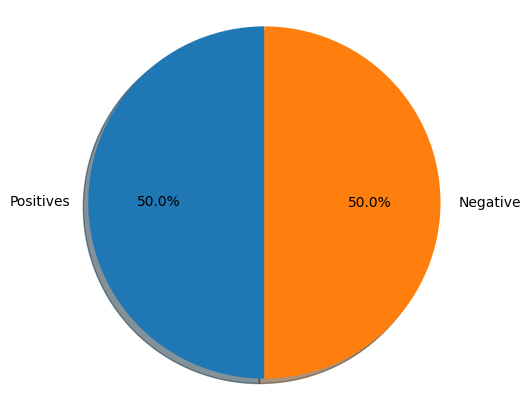

In [8]:
# Declare a figure with a custom size
fig = plt.figure(figsize=(5, 5))

# labels for the two classes
labels = 'Positives', 'Negative'

# Sizes for each slide
sizes = [len(all_positive_tweets), len(all_negative_tweets)] 

# Declare pie chart, where the slices will be ordered and plotted counter-clockwise:
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis('equal')  

# Display the chart
plt.show()

In [90]:
# working with my remote tweet data.
import requests

url = "https://raw.githubusercontent.com/seigdev/resources/refs/heads/main/tweets.json"
file_name = "tweets.json"

response = requests.get(url)

if response.status_code == 200:
    with open(file_name, 'wb') as file:
        file.write(response.content)
    print(f"File '{file_name}' downloaded successfully.")
else:
    print(f"Failed to download the file. Status code: {response.status_code}")


File 'tweets.json' downloaded successfully.


In [91]:
import pandas as pd

# converting the json data to a dataframe
df = pd.read_json('tweets.json')

In [92]:
df["full_text"] = df["tweet"].apply(lambda x : x["full_text"])
df

,tweet,full_text
0,{'edit_info': {'initial': {'editTweetIds': ['1...,@Yadubai_manji Come be like say dem won win le...
1,{'edit_info': {'initial': {'editTweetIds': ['1...,@DaizGone @fredtosan Firing power
2,{'edit_info': {'initial': {'editTweetIds': ['1...,Forest no come play https://t.co/SPGCzuPoMS
3,{'edit_info': {'initial': {'editTweetIds': ['1...,See downgrade https://t.co/FwEOJPo1R4
4,{'edit_info': {'initial': {'editTweetIds': ['1...,🤣🤣🤣 https://t.co/RM2jA1a0B7
...,...,...
11072,{'edit_info': {'initial': {'editTweetIds': ['1...,Gabriel Osho 🦅🇳🇬 \n\nLuton FC center-back don ...
11073,{'edit_info': {'initial': {'editTweetIds': ['1...,KC SAY HIM DEY BALL LIKE DROGBA😂 https://t.co/...
11074,{'edit_info': {'initial': {'editTweetIds': ['1...,Dey invite KC FRESH come Premier Peague show😂😂😂
11075,{'edit_info': {'initial': {'editTweetIds': ['1...,RT @EplPidgin: I miss you like Torres😮‍💨 https...


In [93]:
# preprocessing : applying tokenization, lowercasing, 
# removing stopwords and punctuations and stemming.

import re                                  # library for regular expression operations
import string                              # for string operations

from nltk.corpus import stopwords          # module for stop words that come with NLTK
from nltk.stem import PorterStemmer        # module for stemming
from nltk.tokenize import TweetTokenizer   # module for tokenizing strings
from string import punctuation             # library to remove punctuations
import contractions                        # library to expand contractions

In [94]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/sooreoluwa/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [95]:
def clean_text(text):
    # make text lowercase    
    text = str(text).lower()
    # expand contractions
    text = " ".join([contractions.fix(expanded_word) for expanded_word in text.split()])
    # remove the old style of retweet, RT
    text = re.sub(r'^rt[\s]+', '', text)
    # remove text in square brackets
    text = re.sub('\[.*?\]', '', text)
    # remove links
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    # remove punctuation
    text = re.sub('[%s]' % re.escape(punctuation), '', text)
    # remove new lines
    text = re.sub('\n', '', text)
    # remove words containing numbers
    text = re.sub('\w*\d\w*', '', text)
    return text

In [96]:
# cleaning the full text with the above function
df["cleaned_text"] = df["full_text"].apply(lambda x : clean_text(x))
df

,tweet,full_text,cleaned_text
0,{'edit_info': {'initial': {'editTweetIds': ['1...,@Yadubai_manji Come be like say dem won win le...,yadubaimanji come be like say dem won win league
1,{'edit_info': {'initial': {'editTweetIds': ['1...,@DaizGone @fredtosan Firing power,daizgone fredtosan firing power
2,{'edit_info': {'initial': {'editTweetIds': ['1...,Forest no come play https://t.co/SPGCzuPoMS,forest no come play
3,{'edit_info': {'initial': {'editTweetIds': ['1...,See downgrade https://t.co/FwEOJPo1R4,see downgrade
4,{'edit_info': {'initial': {'editTweetIds': ['1...,🤣🤣🤣 https://t.co/RM2jA1a0B7,🤣🤣🤣
...,...,...,...
11072,{'edit_info': {'initial': {'editTweetIds': ['1...,Gabriel Osho 🦅🇳🇬 \n\nLuton FC center-back don ...,gabriel osho 🦅🇳🇬 luton fc centerback don get h...
11073,{'edit_info': {'initial': {'editTweetIds': ['1...,KC SAY HIM DEY BALL LIKE DROGBA😂 https://t.co/...,kc say him dey ball like drogba😂
11074,{'edit_info': {'initial': {'editTweetIds': ['1...,Dey invite KC FRESH come Premier Peague show😂😂😂,dey invite kc fresh come premier peague show😂😂😂
11075,{'edit_info': {'initial': {'editTweetIds': ['1...,RT @EplPidgin: I miss you like Torres😮‍💨 https...,eplpidgin i miss you like torres😮‍💨


In [97]:
# tokenizing the cleaned text
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)

df["tokenized_text"] = df["cleaned_text"].apply(lambda x : tokenizer.tokenize(x))
df

,tweet,full_text,cleaned_text,tokenized_text
0,{'edit_info': {'initial': {'editTweetIds': ['1...,@Yadubai_manji Come be like say dem won win le...,yadubaimanji come be like say dem won win league,"[yadubaimanji, come, be, like, say, dem, won, ..."
1,{'edit_info': {'initial': {'editTweetIds': ['1...,@DaizGone @fredtosan Firing power,daizgone fredtosan firing power,"[daizgone, fredtosan, firing, power]"
2,{'edit_info': {'initial': {'editTweetIds': ['1...,Forest no come play https://t.co/SPGCzuPoMS,forest no come play,"[forest, no, come, play]"
3,{'edit_info': {'initial': {'editTweetIds': ['1...,See downgrade https://t.co/FwEOJPo1R4,see downgrade,"[see, downgrade]"
4,{'edit_info': {'initial': {'editTweetIds': ['1...,🤣🤣🤣 https://t.co/RM2jA1a0B7,🤣🤣🤣,"[🤣, 🤣, 🤣]"
...,...,...,...,...
11072,{'edit_info': {'initial': {'editTweetIds': ['1...,Gabriel Osho 🦅🇳🇬 \n\nLuton FC center-back don ...,gabriel osho 🦅🇳🇬 luton fc centerback don get h...,"[gabriel, osho, 🦅, 🇳🇬, luton, fc, centerback, ..."
11073,{'edit_info': {'initial': {'editTweetIds': ['1...,KC SAY HIM DEY BALL LIKE DROGBA😂 https://t.co/...,kc say him dey ball like drogba😂,"[kc, say, him, dey, ball, like, drogba, 😂]"
11074,{'edit_info': {'initial': {'editTweetIds': ['1...,Dey invite KC FRESH come Premier Peague show😂😂😂,dey invite kc fresh come premier peague show😂😂😂,"[dey, invite, kc, fresh, come, premier, peague..."
11075,{'edit_info': {'initial': {'editTweetIds': ['1...,RT @EplPidgin: I miss you like Torres😮‍💨 https...,eplpidgin i miss you like torres😮‍💨,"[eplpidgin, i, miss, you, like, torres, 😮‍💨]"


In [98]:
# removing stopwords
def remove_stopword(word_list):
  return [word for word in word_list if word not in stopwords.words('english')]

df["tokenized_text_wo_sw"] = df["tokenized_text"].apply(lambda x: remove_stopword(x))
df

,tweet,full_text,cleaned_text,tokenized_text,tokenized_text_wo_sw
0,{'edit_info': {'initial': {'editTweetIds': ['1...,@Yadubai_manji Come be like say dem won win le...,yadubaimanji come be like say dem won win league,"[yadubaimanji, come, be, like, say, dem, won, ...","[yadubaimanji, come, like, say, dem, win, league]"
1,{'edit_info': {'initial': {'editTweetIds': ['1...,@DaizGone @fredtosan Firing power,daizgone fredtosan firing power,"[daizgone, fredtosan, firing, power]","[daizgone, fredtosan, firing, power]"
2,{'edit_info': {'initial': {'editTweetIds': ['1...,Forest no come play https://t.co/SPGCzuPoMS,forest no come play,"[forest, no, come, play]","[forest, come, play]"
3,{'edit_info': {'initial': {'editTweetIds': ['1...,See downgrade https://t.co/FwEOJPo1R4,see downgrade,"[see, downgrade]","[see, downgrade]"
4,{'edit_info': {'initial': {'editTweetIds': ['1...,🤣🤣🤣 https://t.co/RM2jA1a0B7,🤣🤣🤣,"[🤣, 🤣, 🤣]","[🤣, 🤣, 🤣]"
...,...,...,...,...,...
11072,{'edit_info': {'initial': {'editTweetIds': ['1...,Gabriel Osho 🦅🇳🇬 \n\nLuton FC center-back don ...,gabriel osho 🦅🇳🇬 luton fc centerback don get h...,"[gabriel, osho, 🦅, 🇳🇬, luton, fc, centerback, ...","[gabriel, osho, 🦅, 🇳🇬, luton, fc, centerback, ..."
11073,{'edit_info': {'initial': {'editTweetIds': ['1...,KC SAY HIM DEY BALL LIKE DROGBA😂 https://t.co/...,kc say him dey ball like drogba😂,"[kc, say, him, dey, ball, like, drogba, 😂]","[kc, say, dey, ball, like, drogba, 😂]"
11074,{'edit_info': {'initial': {'editTweetIds': ['1...,Dey invite KC FRESH come Premier Peague show😂😂😂,dey invite kc fresh come premier peague show😂😂😂,"[dey, invite, kc, fresh, come, premier, peague...","[dey, invite, kc, fresh, come, premier, peague..."
11075,{'edit_info': {'initial': {'editTweetIds': ['1...,RT @EplPidgin: I miss you like Torres😮‍💨 https...,eplpidgin i miss you like torres😮‍💨,"[eplpidgin, i, miss, you, like, torres, 😮‍💨]","[eplpidgin, miss, like, torres, 😮‍💨]"


In [99]:
# apply lemmetization to the word list without sw
nltk.download("wordnet")

from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/sooreoluwa/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [100]:
df['tokenized_text_wo_sw'] = df['tokenized_text_wo_sw'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])
df

,tweet,full_text,cleaned_text,tokenized_text,tokenized_text_wo_sw
0,{'edit_info': {'initial': {'editTweetIds': ['1...,@Yadubai_manji Come be like say dem won win le...,yadubaimanji come be like say dem won win league,"[yadubaimanji, come, be, like, say, dem, won, ...","[yadubaimanji, come, like, say, dem, win, league]"
1,{'edit_info': {'initial': {'editTweetIds': ['1...,@DaizGone @fredtosan Firing power,daizgone fredtosan firing power,"[daizgone, fredtosan, firing, power]","[daizgone, fredtosan, firing, power]"
2,{'edit_info': {'initial': {'editTweetIds': ['1...,Forest no come play https://t.co/SPGCzuPoMS,forest no come play,"[forest, no, come, play]","[forest, come, play]"
3,{'edit_info': {'initial': {'editTweetIds': ['1...,See downgrade https://t.co/FwEOJPo1R4,see downgrade,"[see, downgrade]","[see, downgrade]"
4,{'edit_info': {'initial': {'editTweetIds': ['1...,🤣🤣🤣 https://t.co/RM2jA1a0B7,🤣🤣🤣,"[🤣, 🤣, 🤣]","[🤣, 🤣, 🤣]"
...,...,...,...,...,...
11072,{'edit_info': {'initial': {'editTweetIds': ['1...,Gabriel Osho 🦅🇳🇬 \n\nLuton FC center-back don ...,gabriel osho 🦅🇳🇬 luton fc centerback don get h...,"[gabriel, osho, 🦅, 🇳🇬, luton, fc, centerback, ...","[gabriel, osho, 🦅, 🇳🇬, luton, fc, centerback, ..."
11073,{'edit_info': {'initial': {'editTweetIds': ['1...,KC SAY HIM DEY BALL LIKE DROGBA😂 https://t.co/...,kc say him dey ball like drogba😂,"[kc, say, him, dey, ball, like, drogba, 😂]","[kc, say, dey, ball, like, drogba, 😂]"
11074,{'edit_info': {'initial': {'editTweetIds': ['1...,Dey invite KC FRESH come Premier Peague show😂😂😂,dey invite kc fresh come premier peague show😂😂😂,"[dey, invite, kc, fresh, come, premier, peague...","[dey, invite, kc, fresh, come, premier, peague..."
11075,{'edit_info': {'initial': {'editTweetIds': ['1...,RT @EplPidgin: I miss you like Torres😮‍💨 https...,eplpidgin i miss you like torres😮‍💨,"[eplpidgin, i, miss, you, like, torres, 😮‍💨]","[eplpidgin, miss, like, torres, 😮‍💨]"


In [101]:
# join the list of the word to form final text
df['final_text'] = df['tokenized_text_wo_sw'].apply(lambda x:' '.join(x))
df

,tweet,full_text,cleaned_text,tokenized_text,tokenized_text_wo_sw,final_text
0,{'edit_info': {'initial': {'editTweetIds': ['1...,@Yadubai_manji Come be like say dem won win le...,yadubaimanji come be like say dem won win league,"[yadubaimanji, come, be, like, say, dem, won, ...","[yadubaimanji, come, like, say, dem, win, league]",yadubaimanji come like say dem win league
1,{'edit_info': {'initial': {'editTweetIds': ['1...,@DaizGone @fredtosan Firing power,daizgone fredtosan firing power,"[daizgone, fredtosan, firing, power]","[daizgone, fredtosan, firing, power]",daizgone fredtosan firing power
2,{'edit_info': {'initial': {'editTweetIds': ['1...,Forest no come play https://t.co/SPGCzuPoMS,forest no come play,"[forest, no, come, play]","[forest, come, play]",forest come play
3,{'edit_info': {'initial': {'editTweetIds': ['1...,See downgrade https://t.co/FwEOJPo1R4,see downgrade,"[see, downgrade]","[see, downgrade]",see downgrade
4,{'edit_info': {'initial': {'editTweetIds': ['1...,🤣🤣🤣 https://t.co/RM2jA1a0B7,🤣🤣🤣,"[🤣, 🤣, 🤣]","[🤣, 🤣, 🤣]",🤣 🤣 🤣
...,...,...,...,...,...,...
11072,{'edit_info': {'initial': {'editTweetIds': ['1...,Gabriel Osho 🦅🇳🇬 \n\nLuton FC center-back don ...,gabriel osho 🦅🇳🇬 luton fc centerback don get h...,"[gabriel, osho, 🦅, 🇳🇬, luton, fc, centerback, ...","[gabriel, osho, 🦅, 🇳🇬, luton, fc, centerback, ...",gabriel osho 🦅 🇳🇬 luton fc centerback get firs...
11073,{'edit_info': {'initial': {'editTweetIds': ['1...,KC SAY HIM DEY BALL LIKE DROGBA😂 https://t.co/...,kc say him dey ball like drogba😂,"[kc, say, him, dey, ball, like, drogba, 😂]","[kc, say, dey, ball, like, drogba, 😂]",kc say dey ball like drogba 😂
11074,{'edit_info': {'initial': {'editTweetIds': ['1...,Dey invite KC FRESH come Premier Peague show😂😂😂,dey invite kc fresh come premier peague show😂😂😂,"[dey, invite, kc, fresh, come, premier, peague...","[dey, invite, kc, fresh, come, premier, peague...",dey invite kc fresh come premier peague show 😂...
11075,{'edit_info': {'initial': {'editTweetIds': ['1...,RT @EplPidgin: I miss you like Torres😮‍💨 https...,eplpidgin i miss you like torres😮‍💨,"[eplpidgin, i, miss, you, like, torres, 😮‍💨]","[eplpidgin, miss, like, torres, 😮‍💨]",eplpidgin miss like torres 😮‍💨


In [102]:
!pip3 install textblob

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 624 kB 4.4 MB/s eta 0:00:01
You should consider upgrading via the '/Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip' command.


In [103]:
# import textblob to get the sentiment of each text/
from textblob import TextBlob

In [104]:
df['polarity'] = df['cleaned_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
df

,tweet,full_text,cleaned_text,tokenized_text,tokenized_text_wo_sw,final_text,polarity
0,{'edit_info': {'initial': {'editTweetIds': ['1...,@Yadubai_manji Come be like say dem won win le...,yadubaimanji come be like say dem won win league,"[yadubaimanji, come, be, like, say, dem, won, ...","[yadubaimanji, come, like, say, dem, win, league]",yadubaimanji come like say dem win league,0.80
1,{'edit_info': {'initial': {'editTweetIds': ['1...,@DaizGone @fredtosan Firing power,daizgone fredtosan firing power,"[daizgone, fredtosan, firing, power]","[daizgone, fredtosan, firing, power]",daizgone fredtosan firing power,0.00
2,{'edit_info': {'initial': {'editTweetIds': ['1...,Forest no come play https://t.co/SPGCzuPoMS,forest no come play,"[forest, no, come, play]","[forest, come, play]",forest come play,0.00
3,{'edit_info': {'initial': {'editTweetIds': ['1...,See downgrade https://t.co/FwEOJPo1R4,see downgrade,"[see, downgrade]","[see, downgrade]",see downgrade,0.00
4,{'edit_info': {'initial': {'editTweetIds': ['1...,🤣🤣🤣 https://t.co/RM2jA1a0B7,🤣🤣🤣,"[🤣, 🤣, 🤣]","[🤣, 🤣, 🤣]",🤣 🤣 🤣,0.00
...,...,...,...,...,...,...,...
11072,{'edit_info': {'initial': {'editTweetIds': ['1...,Gabriel Osho 🦅🇳🇬 \n\nLuton FC center-back don ...,gabriel osho 🦅🇳🇬 luton fc centerback don get h...,"[gabriel, osho, 🦅, 🇳🇬, luton, fc, centerback, ...","[gabriel, osho, 🦅, 🇳🇬, luton, fc, centerback, ...",gabriel osho 🦅 🇳🇬 luton fc centerback get firs...,0.25
11073,{'edit_info': {'initial': {'editTweetIds': ['1...,KC SAY HIM DEY BALL LIKE DROGBA😂 https://t.co/...,kc say him dey ball like drogba😂,"[kc, say, him, dey, ball, like, drogba, 😂]","[kc, say, dey, ball, like, drogba, 😂]",kc say dey ball like drogba 😂,0.00
11074,{'edit_info': {'initial': {'editTweetIds': ['1...,Dey invite KC FRESH come Premier Peague show😂😂😂,dey invite kc fresh come premier peague show😂😂😂,"[dey, invite, kc, fresh, come, premier, peague...","[dey, invite, kc, fresh, come, premier, peague...",dey invite kc fresh come premier peague show 😂...,0.30
11075,{'edit_info': {'initial': {'editTweetIds': ['1...,RT @EplPidgin: I miss you like Torres😮‍💨 https...,eplpidgin i miss you like torres😮‍💨,"[eplpidgin, i, miss, you, like, torres, 😮‍💨]","[eplpidgin, miss, like, torres, 😮‍💨]",eplpidgin miss like torres 😮‍💨,0.00


In [106]:
# get the sentiment using the polarity value wether positive, negative or neutral
df['sentiment'] = df['polarity'].apply(lambda x: 
        'positive' if x > 0 else 'negative' if x < 0 else 'neutral')
df

,tweet,full_text,cleaned_text,tokenized_text,tokenized_text_wo_sw,final_text,polarity,sentiment
0,{'edit_info': {'initial': {'editTweetIds': ['1...,@Yadubai_manji Come be like say dem won win le...,yadubaimanji come be like say dem won win league,"[yadubaimanji, come, be, like, say, dem, won, ...","[yadubaimanji, come, like, say, dem, win, league]",yadubaimanji come like say dem win league,0.80,positive
1,{'edit_info': {'initial': {'editTweetIds': ['1...,@DaizGone @fredtosan Firing power,daizgone fredtosan firing power,"[daizgone, fredtosan, firing, power]","[daizgone, fredtosan, firing, power]",daizgone fredtosan firing power,0.00,neutral
2,{'edit_info': {'initial': {'editTweetIds': ['1...,Forest no come play https://t.co/SPGCzuPoMS,forest no come play,"[forest, no, come, play]","[forest, come, play]",forest come play,0.00,neutral
3,{'edit_info': {'initial': {'editTweetIds': ['1...,See downgrade https://t.co/FwEOJPo1R4,see downgrade,"[see, downgrade]","[see, downgrade]",see downgrade,0.00,neutral
4,{'edit_info': {'initial': {'editTweetIds': ['1...,🤣🤣🤣 https://t.co/RM2jA1a0B7,🤣🤣🤣,"[🤣, 🤣, 🤣]","[🤣, 🤣, 🤣]",🤣 🤣 🤣,0.00,neutral
...,...,...,...,...,...,...,...,...
11072,{'edit_info': {'initial': {'editTweetIds': ['1...,Gabriel Osho 🦅🇳🇬 \n\nLuton FC center-back don ...,gabriel osho 🦅🇳🇬 luton fc centerback don get h...,"[gabriel, osho, 🦅, 🇳🇬, luton, fc, centerback, ...","[gabriel, osho, 🦅, 🇳🇬, luton, fc, centerback, ...",gabriel osho 🦅 🇳🇬 luton fc centerback get firs...,0.25,positive
11073,{'edit_info': {'initial': {'editTweetIds': ['1...,KC SAY HIM DEY BALL LIKE DROGBA😂 https://t.co/...,kc say him dey ball like drogba😂,"[kc, say, him, dey, ball, like, drogba, 😂]","[kc, say, dey, ball, like, drogba, 😂]",kc say dey ball like drogba 😂,0.00,neutral
11074,{'edit_info': {'initial': {'editTweetIds': ['1...,Dey invite KC FRESH come Premier Peague show😂😂😂,dey invite kc fresh come premier peague show😂😂😂,"[dey, invite, kc, fresh, come, premier, peague...","[dey, invite, kc, fresh, come, premier, peague...",dey invite kc fresh come premier peague show 😂...,0.30,positive
11075,{'edit_info': {'initial': {'editTweetIds': ['1...,RT @EplPidgin: I miss you like Torres😮‍💨 https...,eplpidgin i miss you like torres😮‍💨,"[eplpidgin, i, miss, you, like, torres, 😮‍💨]","[eplpidgin, miss, like, torres, 😮‍💨]",eplpidgin miss like torres 😮‍💨,0.00,neutral


In [116]:
positive_tweets = df[df['sentiment'] == "positive"]['final_text'].tolist()
negative_tweets = df[df['sentiment'] == "negative"]['final_text'].tolist()
tweets = positive_tweets + negative_tweets

In [114]:
# import build_freqs from utils to count how often a word is is associated with the sentiments 
from resources.utils import build_freqs
import numpy as np

In [115]:
# make a numpy array representing labels of the tweets
labels = np.append(np.ones((len(all_positive_tweets))), np.zeros((len(all_negative_tweets))))

In [118]:
# create the frequency dictionary
freqs = build_freqs(tweets, labels)
len(freqs)

4300

In [119]:
freqs

{('yadubaimanji', 1.0): 2,
 ('come', 1.0): 97,
 ('like', 1.0): 143,
 ('say', 1.0): 233,
 ('dem', 1.0): 183,
 ('win', 1.0): 401,
 ('leagu', 1.0): 189,
 ('haaland', 1.0): 45,
 ('go', 1.0): 541,
 ('still', 1.0): 57,
 ('golden', 1.0): 13,
 ('boot', 1.0): 10,
 ('sha', 1.0): 16,
 ('highest', 1.0): 10,
 ('way', 1.0): 147,
 ('man', 1.0): 317,
 ('fit', 1.0): 297,
 ('finish', 1.0): 43,
 ('season', 1.0): 178,
 ('na', 1.0): 416,
 ('eplpidgin', 1.0): 578,
 ('dey', 1.0): 970,
 ('confus', 1.0): 6,
 ('person', 1.0): 65,
 ('una', 1.0): 159,
 ('good', 1.0): 131,
 ('abi', 1.0): 8,
 ('nottingham', 1.0): 7,
 ('forest', 1.0): 15,
 ('top', 1.0): 152,
 ('kingviil', 1.0): 1,
 ('best', 1.0): 78,
 ('quot', 1.0): 5,
 ('👏', 1.0): 27,
 ('dremva', 1.0): 1,
 ('tear', 1.0): 10,
 ('sweet', 1.0): 104,
 ('pa', 1.0): 77,
 ('wait', 1.0): 26,
 ('make', 1.0): 224,
 ('match', 1.0): 185,
 ('first', 1.0): 223,
 ('🤣', 1.0): 145,
 ('true', 1.0): 17,
 ('see', 1.0): 142,
 ('nunez', 1.0): 8,
 ('lip', 1.0): 1,
 ('nearli', 1.0): 5,
 (